# Projet : Système de Prédiction de Réussite Étudiante via trace sur ARCHE

Réalisé par : Djekounmian Beramgoto Alexis



Entraînement de deux modèles de prédiction :
- **Régression Linéaire** : Prédire la note exacte
- **Random Forest Classifier** : Prédire Réussite/Échec

## Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

## Chargement des Données

In [2]:
# Chargement
logs = pd.read_csv("logs_info_25_pseudo.csv")
notes = pd.read_csv("notes_info_25_pseudo.csv")
print(logs.head())
logs.describe()

                  date  pseudo  \
0  2024-07-24 09:48:08     436   
1  2024-07-24 09:48:14     436   
2  2024-08-19 12:55:34     841   
3  2024-08-19 17:06:02     898   
4  2024-08-19 17:06:04     898   

                                            contexte composant  \
0  Cours: PASS - S1 - UE Disciplinaire Informatiq...   Système   
1                                   Fichier: Contrat   Fichier   
2  Cours: PASS - S1 - UE Disciplinaire Informatiq...   Système   
3  Cours: PASS - S1 - UE Disciplinaire Informatiq...   Système   
4  Cours: PASS - S1 - UE Disciplinaire Informatiq...   Système   

                        evenement  
0                  Cours consulté  
1        Module de cours consulté  
2                  Cours consulté  
3                  Cours consulté  
4  Liste d’utilisateurs consultée  


,pseudo
count,16227.000000
mean,417.595489
std,264.611682
min,15.000000
25%,121.000000
50%,409.000000
75%,617.000000
max,1000.000000


## Nettoyage des Données

In [3]:
# Nettoyage simple
if ('heure') in logs.columns:
    logs['heure'] = pd.to_datetime(logs['heure'])
elif 'date' in logs.columns:
    logs['date'] = pd.to_datetime(logs['date'])
elif 'time' in logs.columns:
    logs['time'] = pd.to_datetime(logs['time'])
else:
    print(" Colonne de date/heure introuvable. Colonnes disponibles :")
    print(logs.columns.tolist())

logs = logs.dropna()
notes = notes.dropna()

## Construction des Features

In [4]:
# construction des Features
features = logs.groupby("pseudo").agg(
    nb_actions=("evenement", "count"),
    nb_connexions=("composant", lambda x: (x == "login").sum()),
    nb_ressources=("contexte", "nunique")
).reset_index()

data = features.merge(notes, on="pseudo")

## Exploration des Données

In [5]:
print("Shape of data:", data.shape)
print("Columns:", data.columns)
print("Data head:\n", data.head())
print("Any NaN in data?", data.isnull().any().any())

Shape of data: (95, 5)
Columns: Index(['pseudo', 'nb_actions', 'nb_connexions', 'nb_ressources', 'note'], dtype='object')
Data head:
    pseudo  nb_actions  nb_connexions  nb_ressources    note
0      15         116              0             23   8.718
1      19         348              0             48   9.070
2      29          55              0             24   9.917
3      38           4              0              3   8.249
4      42         371              0             72  11.366
Any NaN in data? False


## Définition X / y

In [6]:
# Définition X / y
X = data[["nb_actions", "nb_connexions", "nb_ressources"]]
y = data["note"]

In [7]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("y dtype:", y.dtype)
print("X dtypes:\n", X.dtypes)

X shape: (95, 3)
y shape: (95,)
y dtype: float64
X dtypes:
 nb_actions       int64
nb_connexions    int64
nb_ressources    int64
dtype: object


## Régression Multiple (Prédiction de la Note)

In [8]:
# Régression multiple
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
reg = LinearRegression()
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_pred = reg.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("RMSE régression :", rmse)

RMSE régression : 0.8694280504730333


## Classification (Réussite/Échec)

In [11]:
# Version classification (réussite/échec)
data["reussite"] = (data["note"] >= 10).astype(int)
y_class = data["reussite"]

In [12]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_class.iloc[X_train.index])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
y_pred_class = rf.predict(X_test)
acc = accuracy_score(y_class.iloc[X_test.index], y_pred_class)

print("Accuracy Random Forest :", acc)

Accuracy Random Forest : 0.5789473684210527


## Résumé des Résultats

In [14]:
print("="*50)
print("RÉSUMÉ DES PERFORMANCES")
print("="*50)
print(f"Régression Linéaire - RMSE : {rmse:.4f}")
print(f"Random Forest - Accuracy : {acc:.4f}")
print("="*50)

RÉSUMÉ DES PERFORMANCES
Régression Linéaire - RMSE : 0.8694
Random Forest - Accuracy : 0.5789


## Analyse des Coefficients (Régression)

In [15]:
# Affichage des coefficients de la régression
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": reg.coef_
})
coefficients = coefficients.sort_values("Coefficient", ascending=False)

print("\nCoefficients de la Régression Linéaire :")
print(coefficients.to_string(index=False))
print(f"\nIntercept : {reg.intercept_:.4f}")


Coefficients de la Régression Linéaire :
      Feature  Coefficient
nb_ressources     0.017863
   nb_actions     0.000617
nb_connexions     0.000000

Intercept : 9.4830


## Importance des Features (Random Forest)

In [16]:
# Importance des features du Random Forest
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values("Importance", ascending=False)

print("\nImportance des Features (Random Forest) :")
print(importance.to_string(index=False))


Importance des Features (Random Forest) :
      Feature  Importance
   nb_actions     0.53469
nb_ressources     0.46531
nb_connexions     0.00000


## Visualisations

In [17]:
import matplotlib.pyplot as plt
import numpy as np

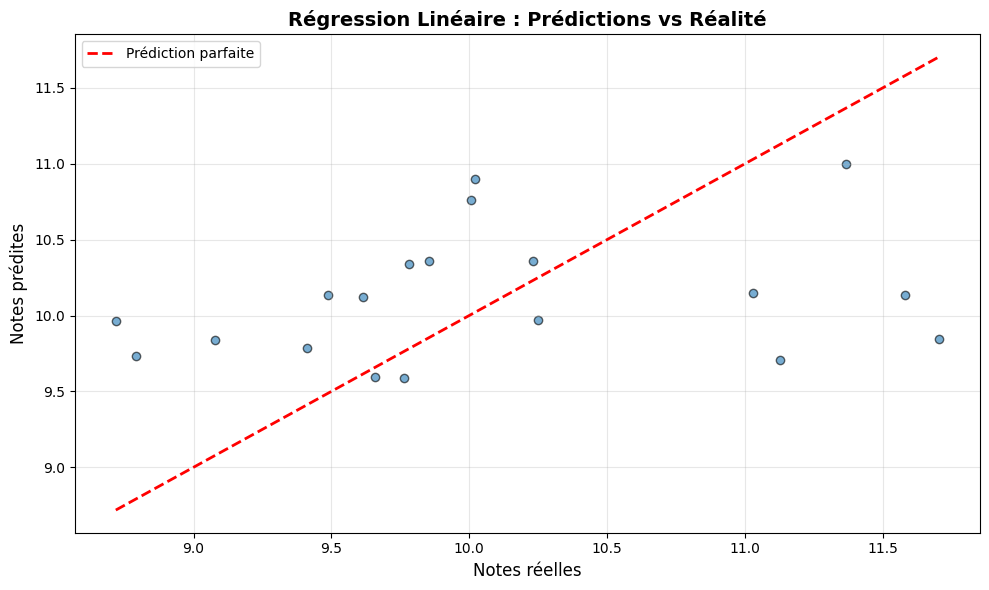

In [18]:
# Visualisation Régression : Prédictions vs Réalité
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Prédiction parfaite')
plt.xlabel('Notes réelles', fontsize=12)
plt.ylabel('Notes prédites', fontsize=12)
plt.title('Régression Linéaire : Prédictions vs Réalité', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

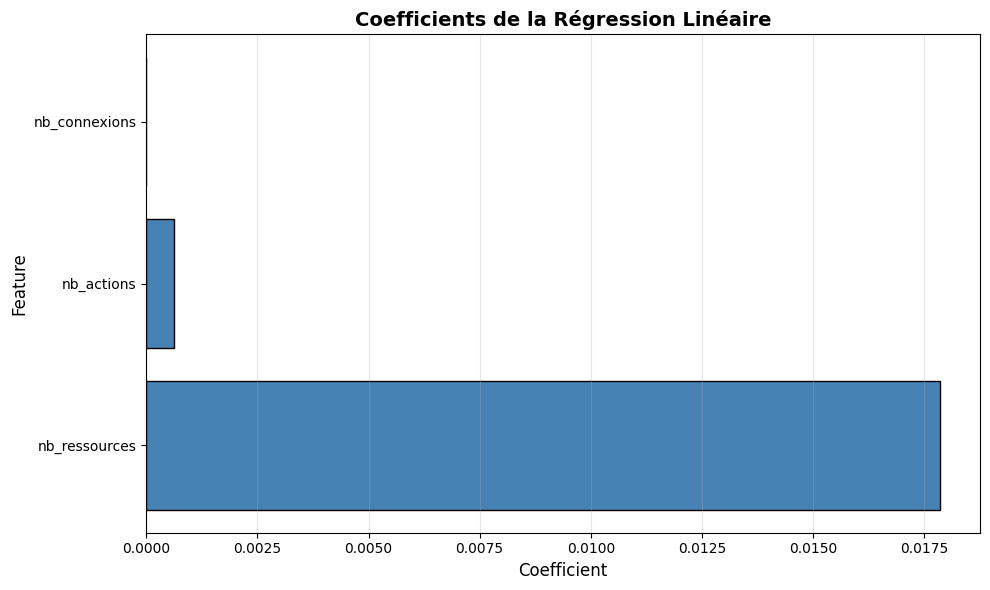

In [19]:
# Visualisation des coefficients
plt.figure(figsize=(10, 6))
plt.barh(coefficients["Feature"], coefficients["Coefficient"], color='steelblue', edgecolor='black')
plt.xlabel('Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Coefficients de la Régression Linéaire', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

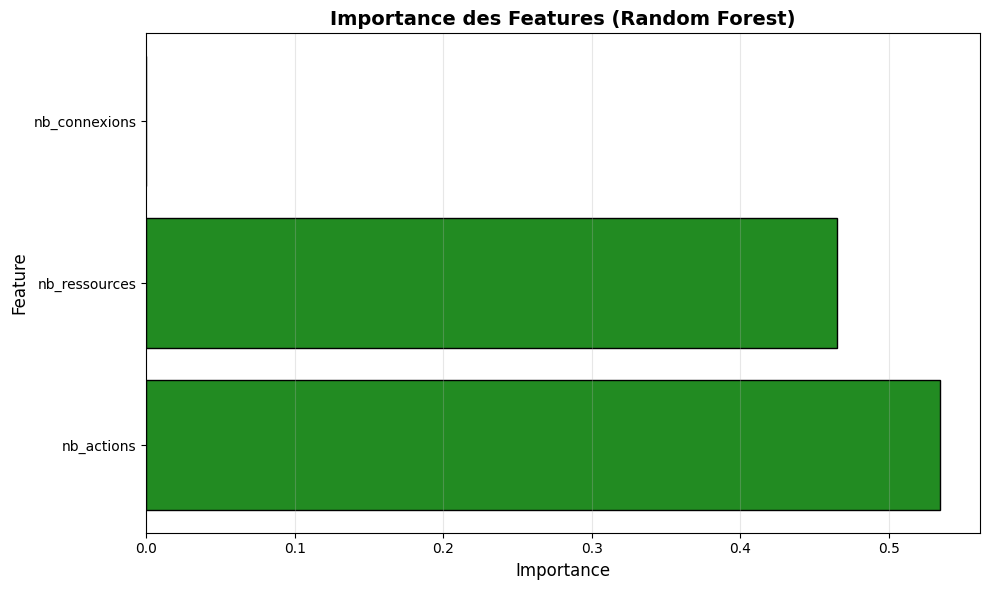

In [20]:
# Visualisation de l'importance des features
plt.figure(figsize=(10, 6))
plt.barh(importance["Feature"], importance["Importance"], color='forestgreen', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Importance des Features (Random Forest)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

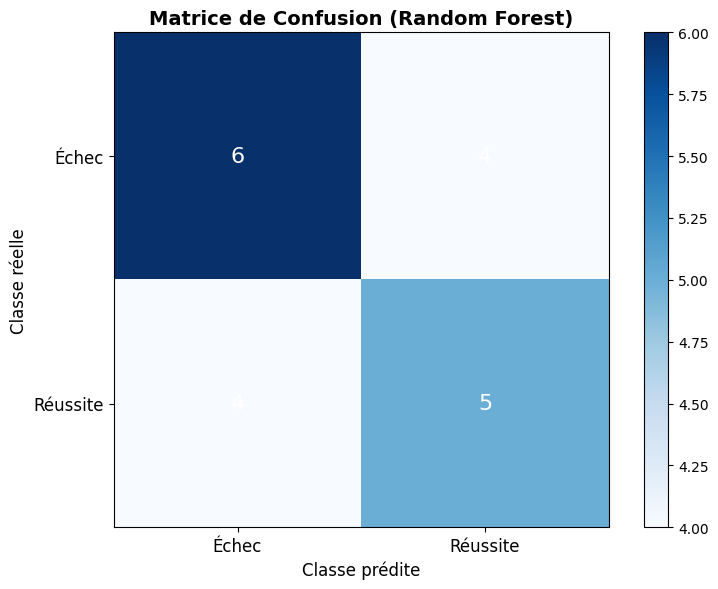

In [21]:
# Distribution des prédictions de classification
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_class.iloc[X_test.index], y_pred_class)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion (Random Forest)', fontsize=14, fontweight='bold')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Échec', 'Réussite'], fontsize=12)
plt.yticks(tick_marks, ['Échec', 'Réussite'], fontsize=12)

# Ajouter les valeurs dans les cellules
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=16)

plt.ylabel('Classe réelle', fontsize=12)
plt.xlabel('Classe prédite', fontsize=12)
plt.tight_layout()
plt.show()

## Sauvegarde des Modèles

In [22]:
import joblib

# Sauvegarde les modèles
joblib.dump(reg, "model_regression.pkl")
joblib.dump(rf, "model_random_forest.pkl")

print("Modèles sauvegardés :")
print("   - model_regression.pkl")
print("   - model_random_forest.pkl")

Modèles sauvegardés :
   - model_regression.pkl
   - model_random_forest.pkl


## Conclusion

### Modèles Entraînés :
1. **Régression Linéaire** : Prédit la note exacte (0-20)
2. **Random Forest Classifier** : Prédit Réussite (≥10) ou Échec (<10)

### Features Utilisées :
- `nb_actions` : Nombre total d'actions/événements
- `nb_connexions` : Nombre de connexions (login)
- `nb_ressources` : Nombre de contextes/ressources uniques

### Fichiers Générés :
- `model_regression.pkl` : Modèle de régression
- `model_random_forest.pkl` : Modèle de classification